In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from time import perf_counter

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


# Ex.1 - Stokes: GMRES and optimal preconditioning

We consider the following cavity problem

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,1)^2, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4.\\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus\Gamma_4, \\
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D} = 1\boldsymbol{i}$. We solve this problem using GMRES and the optimal preconditioners

$$
\begin{bmatrix}
A & 0 \\
0 & \frac{1}{\nu}M_p
\end{bmatrix}, \quad \quad 
\begin{bmatrix}
A & 0 \\
\pm B & \frac{1}{\nu}M_p
\end{bmatrix}.
$$

with $\nu = 1$.

### Notation for `fieldsplit`

__Block diagonal preconditioner.__

$$
\Sigma = \begin{bmatrix} \Sigma_{00} & \Sigma_{01} \\ \Sigma_{10} & \Sigma_{11} \end{bmatrix} = \begin{bmatrix} A & B^T \\ -B & 0 \end{bmatrix}, \qquad P = \begin{bmatrix} P_0 & 0 \\ 0 & P_1 \end{bmatrix} = \begin{bmatrix} A & 0 \\ 0 & \frac{1}{\nu}M_p \end{bmatrix}
$$

$$
\Sigma\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=\begin{bmatrix} \mathbf{F} \\\mathbf{0} \end{bmatrix}
\longrightarrow
P^{-1}\Sigma\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=P^{-1}\begin{bmatrix} \mathbf{F} \\\mathbf{0} \end{bmatrix}
\leftrightarrow
\begin{bmatrix} P_0^{-1}A & P_0^{-1}B^T \\ -P_1^{-1}B & 0 \end{bmatrix}\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=\begin{bmatrix} P_0^{-1}\mathbf{F} \\\mathbf{0} \end{bmatrix}
$$
so for each of the components $P_0, P_1$ of the preconditioner, we need to be able to "apply its inverse" (or an approximation of it).

__Block (lower) triangular preconditioner.__

$$
\Sigma = \begin{bmatrix} \Sigma_{00} & \Sigma_{01} \\ \Sigma_{10} & \Sigma_{11} \end{bmatrix} = \begin{bmatrix} A & B^T \\ -B & 0 \end{bmatrix}, \qquad P = \begin{bmatrix} P_0 & 0 \\ {\color{red}{P_L}} & P_1 \end{bmatrix} = \begin{bmatrix} A & 0 \\ -B & \frac{1}{\nu}M_p \end{bmatrix}
$$

$$
P\begin{bmatrix} \mathbf{X}_0\\\mathbf{X}_1\end{bmatrix} = \begin{bmatrix} \mathbf{Y}_0\\\mathbf{Y}_1\end{bmatrix}
\quad\rightarrow\quad
\begin{bmatrix} \mathbf{X}_0\\\mathbf{X}_1\end{bmatrix} = \begin{bmatrix} P_0^{-1}\mathbf{Y}_0\\P_1^{-1}(\mathbf{Y}_1-{\color{red}{P_L}}\mathbf{X}_0)\end{bmatrix} = \begin{bmatrix} P_0^{-1}\mathbf{Y}_0\\P_1^{-1}(\mathbf{Y}_1-{\color{red}{P_L}}P_0^{-1}\mathbf{Y}_0)\end{bmatrix}
$$

$$
\Sigma\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=\begin{bmatrix} \mathbf{F} \\\mathbf{0} \end{bmatrix}
\longrightarrow
P^{-1}\Sigma\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=P^{-1}\begin{bmatrix} \mathbf{F} \\\mathbf{0} \end{bmatrix}
\leftrightarrow
\begin{bmatrix} P_0^{-1}A & P_0^{-1}B^T \\ P_1^{-1}(-B-{\color{red}{P_L}}P_0^{-1}A) & -P_1^{-1}{\color{red}{P_L}}B^T \end{bmatrix}\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=\begin{bmatrix} P_0^{-1}\mathbf{F} \\-P_1^{-1}{\color{red}{P_L}}P_0^{-1}\mathbf{F} \end{bmatrix}
$$
so again for $P_0, P_1$ we need to be able to "apply its inverse" (or an approximation of it), whereas for $P_L$ we do not need to invert.

Examples with simpler equations: https://www.firedrakeproject.org/demos/saddle_point_systems.py.html.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


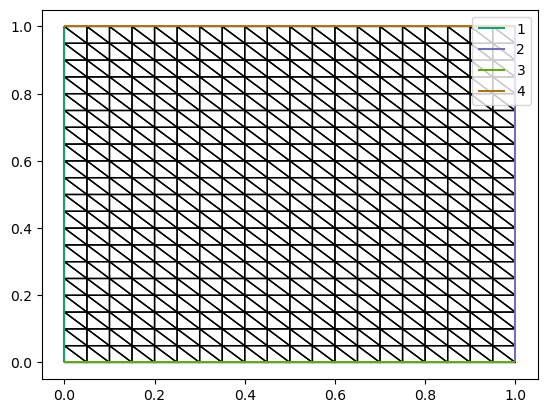

In [2]:
# Build the mesh

N = 20
mesh = UnitSquareMesh(N, N)

fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()

In [4]:
# Stokes problem

# Define function space and trial/test functions for velocity and pressure
V = VectorFunctionSpace(mesh, "P", 2)
Q = FunctionSpace(mesh, "P", 1)
W = MixedFunctionSpace([V, Q])
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
print('Number of DOF \n - u    :',V.dim(),' \n - p    :',Q.dim(),' \n - total:',W.dim(), "\n")

# Other choices of function spaces:

# P1-P0
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'DP', 0) # NB: P0 are DISCONTINUOUS elements (DP)

# # P1-P1
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'P', 1)

# # P1b-P1
# # The enrichment of the velocity space has to be done at the finite element level
# V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
# B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
# V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
# V = FunctionSpace(mesh, V_el)
# Q = FunctionSpace(mesh, 'P', 1)

# Define boundary conditions for velocity (Dirichlet BCs)
bcs = [DirichletBC(W.sub(0), Constant((1.0, 0.0)), 4), # Top boundary
       DirichletBC(W.sub(0), Constant((0.0, 0.0)), (1,2,3)) # Bottom, left, right boundaries
       ]

# Define the variational problem
nu = 1.0
a = Constant(nu) * inner(grad(u), grad(v)) * dx - p * div(v) * dx + q * div(u) * dx
L = inner(Constant((0.0, 0.0)), v) * dx

# Solve the problem passing the null space for fully Dirichlet conditions and 
# using a diagonal preconditioner and a non-diagonal optimal preconditioner
w_h = Function(W)
nullspace = MixedVectorSpaceBasis(W, [W.sub(0), VectorSpaceBasis(constant=True, comm=COMM_WORLD)])

# !!!!!!!!!!!
# Preconditioners forms
Pdiag = nu * inner(grad(u), grad(v)) * dx + 1/nu * p * q * dx
diag_variation_problem = LinearVariationalProblem(a, L, w_h, bcs=bcs, aP=Pdiag)
Ptriang = nu * inner(grad(u), grad(v)) * dx + 1/nu * p * q * dx + q * div(u) * dx
triang_variation_problem = LinearVariationalProblem(a, L, w_h, bcs=bcs, aP=Ptriang)

parameters = {'ksp_type': 'gmres',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000,
              "pc_type": "fieldsplit",                                              # exploit block structure of monolithic matrix
              "pc_fieldsplit_type": "additive",                                     # use a block diagonal preconditioner (taken from pc_form)
              "fieldsplit_0_ksp_type": "preonly", "fieldsplit_0_pc_type": "lu",     # block P0 is "inverted" by LU factorization
              "fieldsplit_1_ksp_type": "preonly", "fieldsplit_1_pc_type": "lu"}     # block P1 is "inverted" by LU factorization
w_h.assign(0)
diagonal_preconditioner_solver = LinearVariationalSolver(diag_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
diagonal_preconditioner_solver.solve()
diagonal_preconditioner_time = perf_counter() - t0

parameters.update({"fieldsplit_0_pc_type": "ilu"})
w_h.assign(0)
diagonal_0ilu_preconditioner_solver = LinearVariationalSolver(diag_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
diagonal_0ilu_preconditioner_solver.solve()
diagonal_0ilu_preconditioner_time = perf_counter() - t0

parameters.update({"fieldsplit_0_pc_type": "lu", "fieldsplit_1_pc_type": "ilu"})
w_h.assign(0)
diagonal_1ilu_preconditioner_solver = LinearVariationalSolver(diag_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
diagonal_1ilu_preconditioner_solver.solve()
diagonal_1ilu_preconditioner_time = perf_counter() - t0

parameters.update({"fieldsplit_0_pc_type": "ilu", "fieldsplit_1_pc_type": "ilu"})
w_h.assign(0)
diagonal_both_ilu_preconditioner_solver = LinearVariationalSolver(diag_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
diagonal_both_ilu_preconditioner_solver.solve()
diagonal_both_ilu_preconditioner_time = perf_counter() - t0

parameters.update({"pc_fieldsplit_type": "multiplicative", "fieldsplit_0_pc_type": "lu", "fieldsplit_1_pc_type": "lu"}) 
w_h.assign(0)
triangular_preconditioner_solver = LinearVariationalSolver(triang_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
triangular_preconditioner_solver.solve()
triangular_preconditioner_time = perf_counter() - t0

parameters.update({"fieldsplit_0_pc_type": "ilu", "fieldsplit_1_pc_type": "lu"}) 
w_h.assign(0)
triangular_0ilu_preconditioner_solver = LinearVariationalSolver(triang_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
triangular_0ilu_preconditioner_solver.solve()
triangular_0ilu_preconditioner_time = perf_counter() - t0

parameters.update({"fieldsplit_0_pc_type": "lu", "fieldsplit_1_pc_type": "ilu"}) 
w_h.assign(0)
triangular_1ilu_preconditioner_solver = LinearVariationalSolver(triang_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
triangular_1ilu_preconditioner_solver.solve()
triangular_1ilu_preconditioner_time = perf_counter() - t0

parameters.update({"fieldsplit_0_pc_type": "ilu", "fieldsplit_1_pc_type": "ilu"}) 
w_h.assign(0)
triangular_both_ilu_preconditioner_solver = LinearVariationalSolver(triang_variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
triangular_both_ilu_preconditioner_solver.solve()
triangular_both_ilu_preconditioner_time = perf_counter() - t0


# Print the number of iterations and the final residual norm
print("GMRES with (block) diagonal preconditioner (tol = 1e-8)")
print("-" * 50)
print("Exact LU for both blocks:")
print("Iterations         :", diagonal_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", diagonal_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", diagonal_preconditioner_time, "s")
print("")
print("ILU for block 0, exact LU for block 1:")
print("Iterations         :", diagonal_0ilu_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", diagonal_0ilu_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", diagonal_0ilu_preconditioner_time, "s")
print("")
print("Exact LU for block 0, ILU for block 1:")
print("Iterations         :", diagonal_1ilu_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", diagonal_1ilu_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", diagonal_1ilu_preconditioner_time, "s")
print("")
print("ILU for both blocks:")
print("Iterations         :", diagonal_both_ilu_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", diagonal_both_ilu_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", diagonal_both_ilu_preconditioner_time, "s")
print("")
print("GMRES with (block) lower triangular preconditioner (tol = 1e-8)")
print("-" * 50)
print("Exact LU for both blocks:")
print("Iterations         :", triangular_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", triangular_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", triangular_preconditioner_time, "s")
print("")
print("ILU for block 0, exact LU for block 1:")
print("Iterations         :", triangular_0ilu_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", triangular_0ilu_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", triangular_0ilu_preconditioner_time, "s")
print("")
print("Exact LU for block 0, ILU for block 1:")
print("Iterations         :", triangular_1ilu_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", triangular_1ilu_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", triangular_1ilu_preconditioner_time, "s")
print("")
print("ILU for both blocks:")
print("Iterations         :", triangular_both_ilu_preconditioner_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", triangular_both_ilu_preconditioner_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", triangular_both_ilu_preconditioner_time, "s")
print("")

Number of DOF 
 - u    : 3362  
 - p    : 441  
 - total: 3803 

GMRES with (block) diagonal preconditioner (tol = 1e-8)
--------------------------------------------------
Exact LU for both blocks:
Iterations         : 49
Final residual norm: 3.1086319167426496e-07
Elapsed time       : 0.0742746209998586 s

ILU for block 0, exact LU for block 1:
Iterations         : 201
Final residual norm: 4.7103800380213435e-07
Elapsed time       : 0.08386581600007048 s

Exact LU for block 0, ILU for block 1:
Iterations         : 51
Final residual norm: 3.5425492573206893e-07
Elapsed time       : 0.07679729600022256 s

ILU for both blocks:
Iterations         : 203
Final residual norm: 5.023708711545215e-07
Elapsed time       : 0.08115263200033951 s

GMRES with (block) lower triangular preconditioner (tol = 1e-8)
--------------------------------------------------
Exact LU for both blocks:
Iterations         : 21
Final residual norm: 4.011919529418358e-07
Elapsed time       : 0.06481308700040245 s

ILU

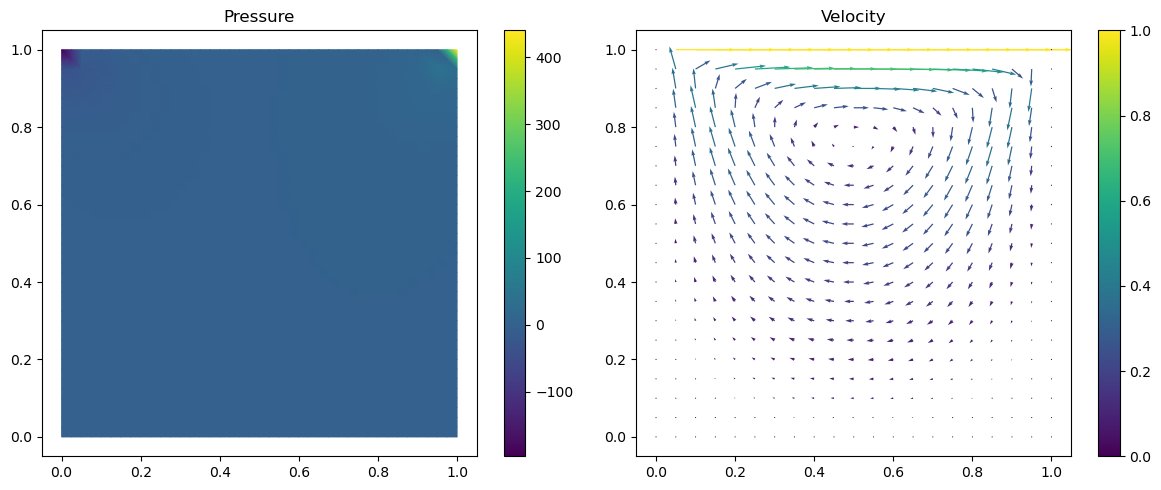

In [6]:
# Plot velocity and pressure
u_h, p_h = w_h.subfunctions

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(p_h, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')

col1 = quiver(u_h, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Velocity')

plt.tight_layout()

Let's now investigate the eigenvalues of the nonpreconditioned system and the one with a block diagonal preconditioner.

SPECTRUM OF THE ORIGINAL MATRIX
503 eigenvalues, of which:
    1 equal to 0 (nullspace)
    80 equal to 1
    1 negative
    422 positive != 1
SPECTRUM OF THE PRECONDITIONED MATRIX
503 eigenvalues, of which:
    1 equal to 0 (dim(nullspace=1))
    382 equal to 1 (dim(Vh)-dim(Qh) = 381)
    0 negative (dim(Qh) = 61)
    120 positive != 1 (dim(Qh) = 61)


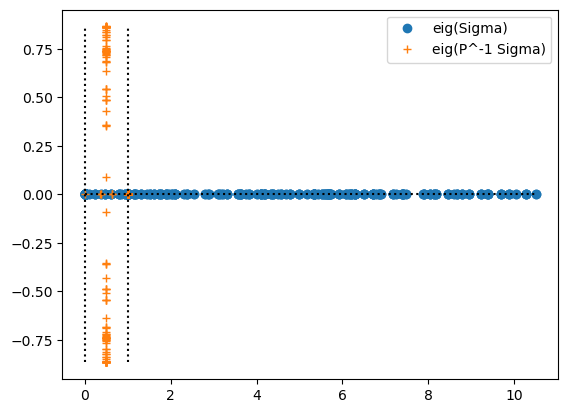

In [8]:
# Small problem to investigate eigenvalues
N=5
mesh = UnitSquareMesh(N, N, diagonal='crossed')
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

bc4 = DirichletBC(W.sub(0), Constant((1., 0.)), 4)
bcRest = DirichletBC(W.sub(0), Constant((0., 0.)), [1,2,3])
bcs = (bc4, bcRest)

# The cavity problem entails a non-trivial nullspace of the matrix, so counting
# the eigenvalues in the clusters is slightly more complex than what theory suggests.
# The clusters expected from the theory can be observed if at least a portion
# of the boundary has Neumann conditions, as in the following Poiseuille problem
# --- uncomment these bcs to change problem ---
# bcs = ( DirichletBC(W.sub(0), Constant((0.,0.)), [3, 4]),
#         DirichletBC(W.sub(0), as_vector((x[1]*(1-x[1]),0.0)), 1)
#        )

# Problem matrix
a = inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
L = inner(Constant((0.0,0.0)), v) * dx
Sigma = assemble(a, bcs=bcs).M.values

# Preconditioner
myPCform = inner(grad(u), grad(v)) * dx + p * q * dx
P = assemble(myPCform, bcs=bcs).M.values

ll, vv = np.linalg.eig(Sigma)
true_nullspace = vv[:, abs(ll)<1e-14]

import scipy as sp # numpy
prec_ll, prec_vv = sp.linalg.eig(Sigma, P)
true_nullspace = prec_vv[:, abs(prec_ll)<1e-14]

np.set_printoptions(precision=2)
np.set_printoptions(linewidth=400)
np.set_printoptions(suppress=True)

plt.plot(ll, np.imag(ll), marker='o', linestyle='none', label='eig(Sigma)')
plt.plot(prec_ll, np.imag(prec_ll), marker='+', linestyle='none', label='eig(P^-1 Sigma)')
plt.plot([1, 1], [ min([min(np.imag(ll)), min(np.imag(prec_ll))]), max([max(np.imag(ll)), max(np.imag(prec_ll))]) ], 'k:')
plt.plot([0, 0], [ min([min(np.imag(ll)), min(np.imag(prec_ll))]), max([max(np.imag(ll)), max(np.imag(prec_ll))]) ], 'k:')
plt.plot([ min([min(np.real(ll)), min(np.real(prec_ll))]), max([max(np.real(ll)), max(np.real(prec_ll))]) ], [0, 0], 'k:')
plt.legend()

tol = 1e-10
print('SPECTRUM OF THE ORIGINAL MATRIX')
print(ll.size, 'eigenvalues, of which:')
print('   ', np.sum(abs(ll)<tol), 'equal to 0 (nullspace)')
print('   ', np.sum(abs(ll-1)<tol), 'equal to 1')
print('   ', np.sum(ll < 0), 'negative')
print('   ', np.sum(ll > 0)-np.sum(abs(ll-1)<tol), 'positive != 1')
print('SPECTRUM OF THE PRECONDITIONED MATRIX')
print(prec_ll.size, 'eigenvalues, of which:')
print('   ', np.sum(abs(prec_ll)<tol), 'equal to 0 (dim(nullspace=1))')
print('   ', np.sum(abs(prec_ll-1)<tol), 'equal to 1 (dim(Vh)-dim(Qh) =', str(V.dim()-Q.dim()) + ')')
print('   ', np.sum(prec_ll.real < -tol), 'negative (dim(Qh) =', str(Q.dim()) + ')')
print('   ', np.sum(prec_ll.real > tol)-np.sum(abs(prec_ll-1)<tol), 'positive != 1 (dim(Qh) =', str(Q.dim()) + ')')